Normal Distribution


Enter mean (μ):  50
Enter standard deviation (σ):  10



Exponential Distribution


Enter rate parameter (λ):  0.5



Central Limit Theorem


Enter population mean:  100
Enter population standard deviation:  20
Enter sample size (n):  30
Enter number of samples:  1000



        DISTRIBUTION ANALYSIS

Normal Distribution
-------------------
Mean     = 50.0000
Variance = 100.0000

Exponential Distribution
------------------------
Mean     = 2.0000
Variance = 4.0000

Central Limit Theorem
---------------------
Population Mean       = 100.0000
Population Std Dev    = 20.0000
Sample Size            = 30
Number of Samples      = 1000
Theoretical Mean       = 100.0000
Theoretical Std Error  = 3.6515
Observed Sample Mean   = 99.9829
Observed Std Dev       = 3.5349


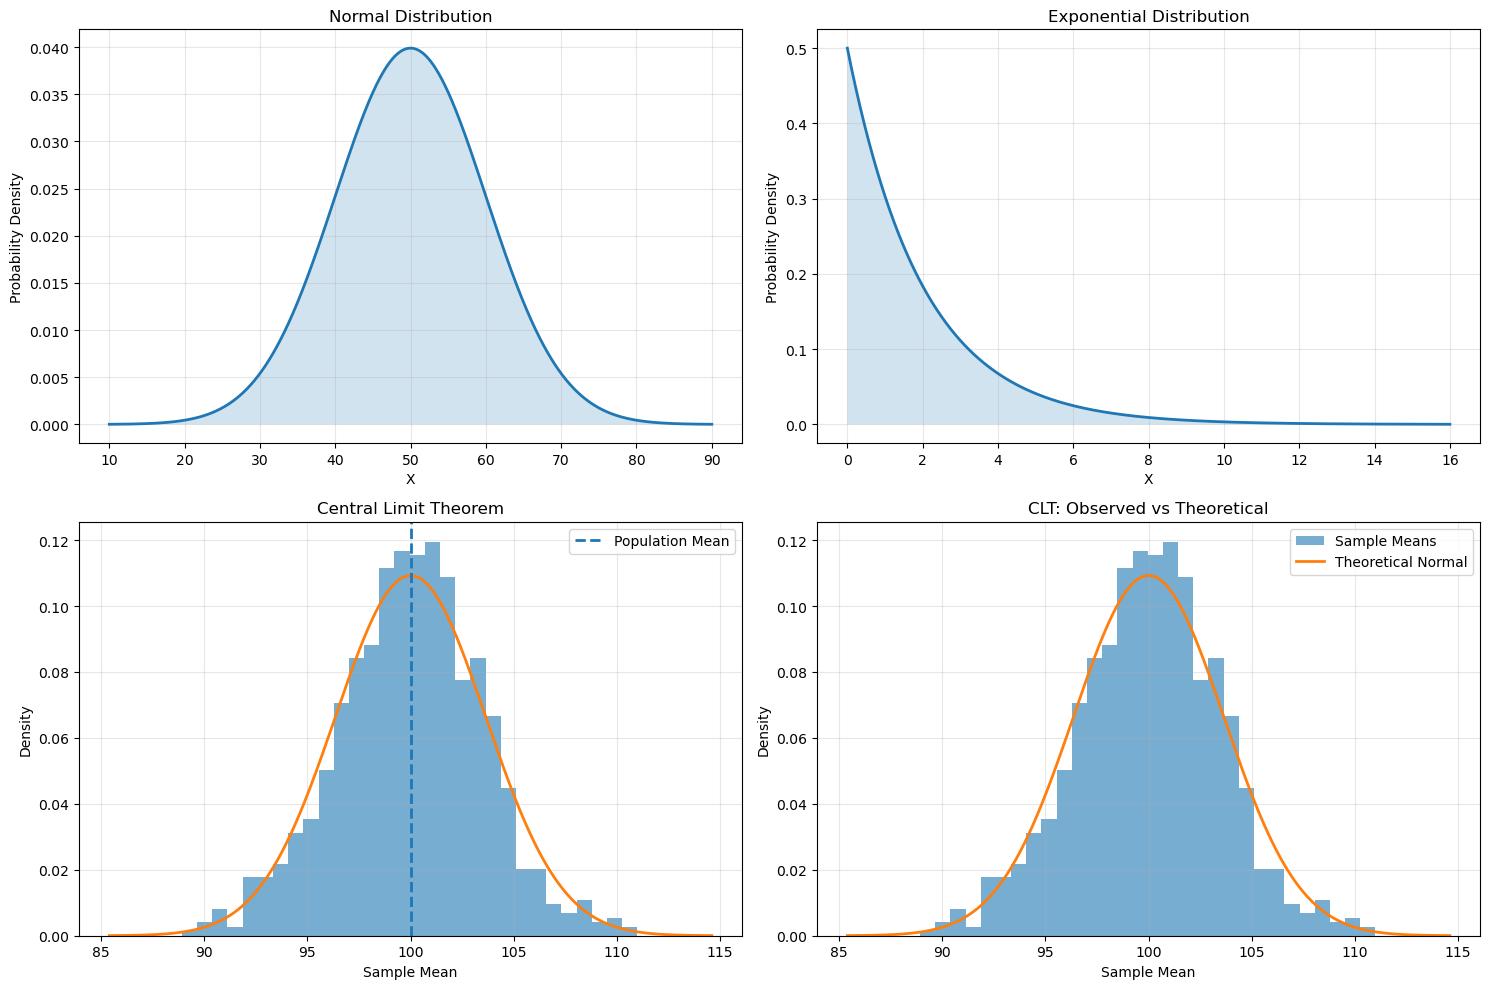

In [2]:
##Plot and analyze Normal and Exponential continuous probability distributions and demonstrate the Central Limit Theorem.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon
# ============================================================
# DYNAMIC INPUT
# ============================================================
print("Normal Distribution")
mu = float(input("Enter mean (μ): "))
sigma = float(input("Enter standard deviation (σ): "))
print("\nExponential Distribution")
lam = float(input("Enter rate parameter (λ): "))
print("\nCentral Limit Theorem")
population_mean = float(input("Enter population mean: "))
population_std = float(input("Enter population standard deviation: "))
sample_size = int(input("Enter sample size (n): "))
num_samples = int(input("Enter number of samples: "))
# ============================================================
# VALIDATION
# ============================================================
if sigma <= 0:
    raise ValueError("Standard deviation must be greater than 0.")
if lam <= 0:
    raise ValueError("Lambda must be greater than 0.")
if population_std <= 0:
    raise ValueError("Population standard deviation must be greater than 0.")
if sample_size <= 0:
    raise ValueError("Sample size must be greater than 0.")
if num_samples <= 0:
    raise ValueError("Number of samples must be greater than 0.")
# ============================================================
# 1. NORMAL DISTRIBUTION
# ============================================================
x_normal = np.linspace(
    mu - 4 * sigma,
    mu + 4 * sigma,
    1000
)
normal_probability = norm.pdf(
    x_normal,
    loc=mu,
    scale=sigma
)
# Mean and variance
normal_mean = mu
normal_variance = sigma ** 2
# ============================================================
# 2. EXPONENTIAL DISTRIBUTION
# ============================================================
# Choose a suitable range automatically
x_exponential = np.linspace(
    0,
    8 / lam,
    1000
)
exponential_probability = expon.pdf(
    x_exponential,
    scale=1 / lam
)
# Mean and variance
exponential_mean = 1 / lam
exponential_variance = 1 / (lam ** 2)
# ============================================================
# 3. CENTRAL LIMIT THEOREM
# ============================================================
# Generate population
population = np.random.normal(
    population_mean,
    population_std,
    100000
)
# Generate sample means
sample_means = []
for i in range(num_samples):
    sample = np.random.choice(
        population,
        size=sample_size,
        replace=True
    )

    sample_means.append(np.mean(sample))
sample_means = np.array(sample_means)
# Theoretical standard error
standard_error = population_std / np.sqrt(sample_size)
# Theoretical CLT distribution
x_clt = np.linspace(
    population_mean - 4 * standard_error,
    population_mean + 4 * standard_error,
    1000
)
clt_probability = norm.pdf(
    x_clt,
    population_mean,
    standard_error
)
# ============================================================
# DISPLAY RESULTS
# ============================================================
print("\n====================================")
print("        DISTRIBUTION ANALYSIS")
print("====================================")
print("\nNormal Distribution")
print("-------------------")
print(f"Mean     = {normal_mean:.4f}")
print(f"Variance = {normal_variance:.4f}")
print("\nExponential Distribution")
print("------------------------")
print(f"Mean     = {exponential_mean:.4f}")
print(f"Variance = {exponential_variance:.4f}")
print("\nCentral Limit Theorem")
print("---------------------")
print(f"Population Mean       = {population_mean:.4f}")
print(f"Population Std Dev    = {population_std:.4f}")
print(f"Sample Size            = {sample_size}")
print(f"Number of Samples      = {num_samples}")
print(f"Theoretical Mean       = {population_mean:.4f}")
print(f"Theoretical Std Error  = {standard_error:.4f}")
print(f"Observed Sample Mean   = {np.mean(sample_means):.4f}")
print(f"Observed Std Dev       = {np.std(sample_means):.4f}")
# ============================================================
# VISUALIZATION
# ============================================================
plt.figure(figsize=(15, 10))
# ------------------------------------------------------------
# NORMAL DISTRIBUTION
# ------------------------------------------------------------
plt.subplot(2, 2, 1)
plt.plot(
    x_normal,
    normal_probability,
    linewidth=2
)
plt.fill_between(
    x_normal,
    normal_probability,
    alpha=0.2
)
plt.title("Normal Distribution")
plt.xlabel("X")
plt.ylabel("Probability Density")
plt.grid(alpha=0.3)
# ------------------------------------------------------------
# EXPONENTIAL DISTRIBUTION
# ------------------------------------------------------------
plt.subplot(2, 2, 2)
plt.plot(
    x_exponential,
    exponential_probability,
    linewidth=2
)
plt.fill_between(
    x_exponential,
    exponential_probability,
    alpha=0.2
)
plt.title("Exponential Distribution")
plt.xlabel("X")
plt.ylabel("Probability Density")
plt.grid(alpha=0.3)
# ------------------------------------------------------------
# CLT - SAMPLE MEANS
# ------------------------------------------------------------
plt.subplot(2, 2, 3)
plt.hist(
    sample_means,
    bins=30,
    density=True,
    alpha=0.6
)
plt.plot(
    x_clt,
    clt_probability,
    linewidth=2
)
plt.axvline(
    population_mean,
    linestyle="--",
    linewidth=2,
    label="Population Mean"
)
plt.title("Central Limit Theorem")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
# ------------------------------------------------------------
# CLT COMPARISON
# ------------------------------------------------------------
plt.subplot(2, 2, 4)
plt.hist(
    sample_means,
    bins=30,
    density=True,
    alpha=0.6,
    label="Sample Means"
)
plt.plot(
    x_clt,
    clt_probability,
    linewidth=2,
    label="Theoretical Normal"
)
plt.title("CLT: Observed vs Theoretical")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()